Saved plot to: learning_curve_average_std.png


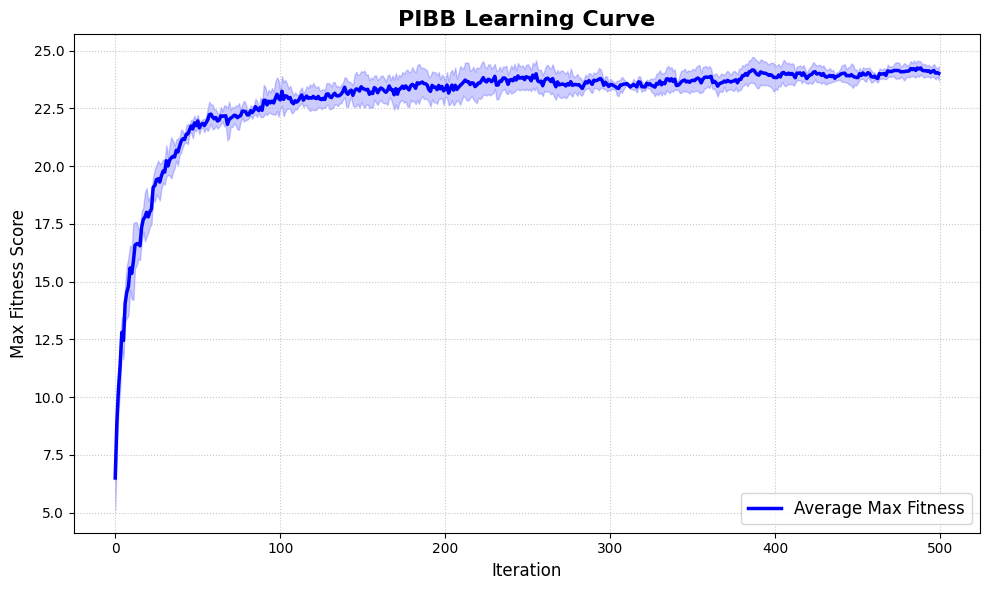

In [1]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# CONFIGURATION
# ==========================================
# List the three specific files you want to average







TARGET_LOG_FILES = [
    "data/pibb_logs/pibb_training_20260723_133412.json", 
    "data/pibb_logs/pibb_training_20260723_153204.json",           
    "data/pibb_logs/pibb_training_20260723_133525.json"           
]

# Solid Ground
# pibb_training_20260711_144156
# pibb_training_20260711_132535
# pibb_training_20260711_053503

# Soft Ground
# pibb_training_20260712_205928
# pibb_training_20260712_224908
# pibb_training_20260713_002747

# Muddy Ground
# pibb_training_20260713_030112
# pibb_training_20260713_145730
# pibb_training_20260713_171538

# Slippery Ground
# pibb_training_20260713_183957
# pibb_training_20260713_200019
# pibb_training_20260713_211705

# Rough Ground
# pibb_training_20260714_113735 @ 162 th iteration
# pibb_training_20260714_150136 @ 191 th iteration
# pibb_training_20260714_161453 @ 191 th iteration


# Water Surface
# pibb_training_20260715_154125 
# pibb_training_20260715_205348
# pibb_training_20260715_224410 (Not learn)


def plot_average_with_std():
    fig, ax = plt.subplots(figsize=(10, 6))
    
    all_runs_max_fitness = []
    iterations_reference = None

    # 1. Read all files and extract the data
    for file_path in TARGET_LOG_FILES:
        if not os.path.exists(file_path):
            print(f"Warning: Could not find file {file_path}")
            continue

        with open(file_path, 'r') as f:
            log_data = json.load(f)

        current_iterations = []
        current_max_fitness = []
        
        for entry in log_data:
            current_iterations.append(entry["iteration"])
            current_max_fitness.append(entry["metrics"]["max_fitness"])
            
        all_runs_max_fitness.append(current_max_fitness)
        
        # Save the iteration numbers from the first file to use for the X-axis
        if iterations_reference is None:
            iterations_reference = current_iterations

    if len(all_runs_max_fitness) == 0:
        print("Error: No valid files were found to plot. Check your file paths!")
        return

    # 2. Safety Check: Ensure all arrays are the same length in case a run stopped early
    min_length = min(len(run) for run in all_runs_max_fitness)
    iterations = iterations_reference[:min_length]
    trimmed_fitness_arrays = [run[:min_length] for run in all_runs_max_fitness]

    # Convert to a 2D NumPy array for easy math (Shape: runs x iterations)
    fitness_matrix = np.array(trimmed_fitness_arrays)

    # 3. Calculate Mean and Standard Deviation across the column axis (axis=0)
    mean_fitness = np.mean(fitness_matrix, axis=0)
    std_fitness = np.std(fitness_matrix, axis=0)

    # 4. Plot the Mean Line
    ax.plot(iterations, mean_fitness, label="Average Max Fitness", color="blue", linewidth=2.5)

    # 5. Plot the Standard Deviation shaded region
    ax.fill_between(
        iterations, 
        mean_fitness - std_fitness, 
        mean_fitness + std_fitness, 
        color="blue", 
        alpha=0.2, 
    )

    # Format the plot
    ax.set_title(f'PIBB Learning Curve', fontsize=16, fontweight='bold')
    ax.set_xlabel('Iteration', fontsize=12)
    ax.set_ylabel('Max Fitness Score', fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.7)
    
    # Add legend
    ax.legend(fontsize=12, loc='lower right')
    
    # Save the plot
    save_path = "learning_curve_average_std.png"
    plt.savefig(save_path, dpi=300)
    print(f"Saved plot to: {save_path}")
    
    # Show the plot
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_average_with_std()

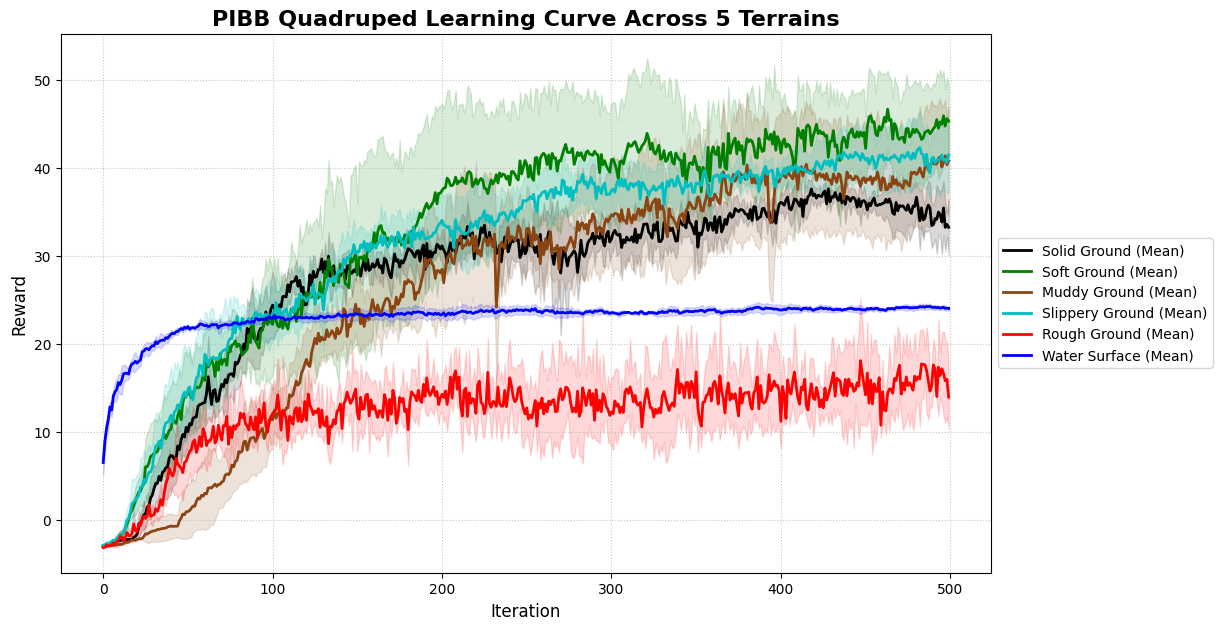

In [2]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# CONFIGURATION
# ==========================================
# Group the log files by terrain type based on your training history
LOG_GROUPS = {
    "Solid Ground": [
        "data/pibb_logs/pibb_training_20260711_144156.json",
        "data/pibb_logs/pibb_training_20260711_132535.json",
        "data/pibb_logs/pibb_training_20260711_053503.json"
    ],
    "Soft Ground": [
        "data/pibb_logs/pibb_training_20260712_205928.json",
        "data/pibb_logs/pibb_training_20260712_224908.json",
        "data/pibb_logs/pibb_training_20260713_002747.json"
    ],
    "Muddy Ground": [
        "data/pibb_logs/pibb_training_20260713_030112.json",
        "data/pibb_logs/pibb_training_20260713_145730.json",
        "data/pibb_logs/pibb_training_20260713_171538.json"
    ],
    "Slippery Ground": [
        "data/pibb_logs/pibb_training_20260713_183957.json",
        "data/pibb_logs/pibb_training_20260713_200019.json",
        "data/pibb_logs/pibb_training_20260713_211705.json"
    ],
    "Rough Ground": [
        "data/pibb_logs/pibb_training_20260714_102519.json", 
        "data/pibb_logs/pibb_training_20260714_130900.json",           
        "data/pibb_logs/pibb_training_20260714_150136.json"
    ],
    "Water Surface": [
		"data/pibb_logs/pibb_training_20260723_133412.json", 
        "data/pibb_logs/pibb_training_20260723_153204.json",           
        "data/pibb_logs/pibb_training_20260723_133525.json"          
	]
}

# Assign a distinct, readable color to each terrain type
COLORS = {
    "Solid Ground": "black",
    "Soft Ground": "green",
    "Muddy Ground": "saddlebrown",
    "Slippery Ground": "c",       # Cyan
    "Rough Ground": "red",
    "Water Surface": "blue"
}

def plot_all_environments():
    fig, ax = plt.subplots(figsize=(12, 7))

    # Loop through each terrain type and its corresponding files
    for terrain_name, file_paths in LOG_GROUPS.items():
        all_runs_max_fitness = []
        iterations_reference = None
        color = COLORS[terrain_name]

        # 1. Read the files for the current terrain
        for file_path in file_paths:
            if not os.path.exists(file_path):
                print(f"Warning: Could not find file {file_path}")
                continue

            with open(file_path, 'r') as f:
                log_data = json.load(f)

            current_iterations = []
            current_max_fitness = []
            
            for entry in log_data:
                current_iterations.append(entry["iteration"])
                current_max_fitness.append(entry["metrics"]["max_fitness"])
                
            all_runs_max_fitness.append(current_max_fitness)
            
            if iterations_reference is None:
                iterations_reference = current_iterations

        if len(all_runs_max_fitness) == 0:
            print(f"Skipping {terrain_name}: No valid files found.")
            continue

        # 2. Safety Check: Truncate to the shortest run in this specific terrain group
        min_length = min(len(run) for run in all_runs_max_fitness)
        iterations = iterations_reference[:min_length]
        trimmed_fitness_arrays = [run[:min_length] for run in all_runs_max_fitness]

        # 3. Calculate Mean and Standard Deviation
        fitness_matrix = np.array(trimmed_fitness_arrays)
        mean_fitness = np.mean(fitness_matrix, axis=0)
        std_fitness = np.std(fitness_matrix, axis=0)

        # 4. Plot the Mean Line and Standard Deviation shaded region
        ax.plot(iterations, mean_fitness, label=f"{terrain_name} (Mean)", color=color, linewidth=2.0)
        ax.fill_between(
            iterations, 
            mean_fitness - std_fitness, 
            mean_fitness + std_fitness, 
            color=color, 
            alpha=0.15, # Slightly more transparent since we have 5 overlapping colors
        )

    # ==========================================
    # PLOT FORMATTING
    # ==========================================
    ax.set_title('PIBB Quadruped Learning Curve Across 5 Terrains', fontsize=16, fontweight='bold')
    ax.set_xlabel('Iteration', fontsize=12)
    ax.set_ylabel('Reward', fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.7)
    
    # Place legend outside the plot so it doesn't cover the data lines
    ax.legend(fontsize=10, loc='center left', bbox_to_anchor=(1, 0.5))
    
    # Save and show
    save_path = "learning_curve_5_terrains_comparison.png"
    # plt.savefig(save_path, dpi=300, bbox_inches="tight")
    # print(f"Saved plot to: {save_path}")
    
    plt.show()

if __name__ == "__main__":
    plot_all_environments()